### Setup
- Git clone https://github.com/isl-org/MiDaS.git and cd MiDaS
- Note : Ground_truth heatmap here referes to the output of the ONNX model in x86(host) machine. To run ONNX model and generate ground truth for your image checkout this link https://github.com/isl-org/MiDaS/tree/master/tf

In [1]:
%%cmd
git clone https://github.com/isl-org/MiDaS.git 

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Depth_Estimation>git clone https://github.com/isl-org/MiDaS.git 


fatal: destination path 'MiDaS' already exists and is not an empty directory.



C:\Qualcomm\AIStack\models\Depth_Estimation>

### Importing Packages

In [2]:
import os
import glob
import torch
import utils
import cv2
import argparse
import time
import numpy as np
import torchvision.transforms as transforms
os.environ['model_name']= "midas_v21_small" 


In [3]:
import sys
sys.path.insert(0,"MiDaS")
from midas.model_loader import default_models, load_model

c:\ashwath\envs\python3.8_acer_notebooks\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Downloading model weights
- change model name to "midas_v21_small_256.pt" in "local_filename" and "download_file" to download weights for midas small

In [4]:
import requests
import shutil

def download_file(url):
    local_filename ="MiDaS\\midas_v21_small_256.pt" 
    
    with requests.get(url, stream=True) as r:
        with open(local_filename, 'wb') as f:
            shutil.copyfileobj(r.raw, f)

    return local_filename

download_file("https://github.com/isl-org/MiDaS/releases/download/v2_1/midas_v21_small_256.pt")



'MiDaS\\midas_v21_small_256.pt'

### Generate ONNX model

### Generate ONNX model for midas_v21_small

In [5]:
model_name = os.environ['model_name']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: %s" % device)
model, transform, net_w, net_h = load_model(device, model_path="MiDaS\\midas_v21_small_256.pt", model_type="midas_v21_small_256", optimize=False, height=False, square=False)

dummy_input=torch.randn(1, 3, 512,288) # for 512 x 288 model 
# dummy_input=torch.randn(1, 3, 512,512) # for 512 x 512 model 
# dummy_input=torch.randn(1, 3, 256,256) # for 256 x 256 model 

torch.onnx.export(model, dummy_input, "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\midas_v21_small.onnx" ,opset_version=11, verbose=False)

Device: cpu
Loading weights:  MiDaS\midas_v21_small_256.pt


Using cache found in C:\Users\HCKTest/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master


Model loaded, number of parameters = 21M


C:\Users\HCKTest/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master\geffnet\conv2d_layers.py:47: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  return max((-(i // -s) - 1) * s + (k - 1) * d + 1 - i, 0)
c:\ashwath\envs\python3.8_acer_notebooks\lib\site-packages\torch\onnx\utils.py:702: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applied. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\jit\passes\onnx\constant_fold.cpp:181.)
  _C._jit_pass_onnx_graph_shape_type_inference(
c:\ashwath\envs\python3.8_acer_notebooks\lib\site-packages\torch\onnx\utils.py:1209: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10

### Preprocessing

In [6]:
%%cmd
mkdir MiDaS\raw

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Depth_Estimation>mkdir MiDaS\raw


A subdirectory or file MiDaS\raw already exists.



C:\Qualcomm\AIStack\models\Depth_Estimation>

In [7]:
import cv2
import glob
import os
import numpy as np
from midas.transforms import Resize, PrepareForNet

In [8]:
def preprocess(dataset_folder):
    net_w, net_h = 288, 512 # for 512 x 288 model 
    # net_w, net_h = 512, 512 # for 512 x 512 model 
    # net_w, net_h = 256, 256 # for 256 x 256 model 
    resize_image = Resize(
                    net_w,
                    net_h,
                    resize_target=None,
                    keep_aspect_ratio=False,
                    ensure_multiple_of=32,
                    resize_method="upper_bound",
                    image_interpolation_method=cv2.INTER_CUBIC,
                )
    def compose2(f1, f2):
        return lambda x: f2(f1(x))
    transform = compose2(resize_image, PrepareForNet())

    # get input
    img_names = glob.glob(os.path.join(dataset_folder, "*"))
    num_images = len(img_names)
    output_path = "raw"
    
    # create output folder
    os.makedirs(output_path, exist_ok=True)
    input_image_paths = []
    input_image_shape = []
    print("start processing")
    ind = 1
    
    for i,f in enumerate(img_names):
        if f.endswith(".jpg"):
            print("  processing {} ({}/{})".format(f, i + 1, num_images))
            input_image_paths.append(f)
#             img = utils.read_image(f)
            img = cv2.imread(f)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0
            img_input = transform({"image": img})["image"]
            print(img_input.shape)
            img_input = img_input.transpose((1, 2, 0))#hwc
            print(img_input.shape)
            # print(img_input)

            
            fid = open("MiDaS\\raw\\"+f.split("\\")[-1].replace(".jpg",".raw"), 'wb')
            img_input.tofile(fid)
            fid.close()
    with open("MiDaS\\input_list.txt",'w') as input_list:
        for raw in os.listdir("MiDaS\\raw"):
            if ".raw" in raw:
                input_list.write("raw\\"+raw+"\n")

In [9]:
dataset_folder = "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\input_images"
preprocess(dataset_folder)

start processing
  processing C:\Qualcomm\AIStack\models\Depth_Estimation\assets\input_images\depth.jpg (1/1)
(3, 512, 288)
(512, 288, 3)


### Generate .cpp and .bin files

In [10]:
os.environ['QNN_ROOT']="C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401"
os.environ['PYTHONPATH']= "C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401\\lib\\python"
os.environ['PATH']=os.environ['PATH']+"C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401\\bin\\aarch64-windows-msvc"

In [11]:
import shutil
SDK_dir = "C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401"       # Specify what's QNN SDK used
SDK_lib_dir = SDK_dir + "\\lib\\arm64x-windows-msvc"
SDK_skel = SDK_dir + "\\lib\\hexagon-v73\\unsigned"

# Copy necessary libraries to a common location
libs = ["QnnCpu.dll","QnnHtp.dll", "QnnSystem.dll", "QnnHtpNetRunExtensions.dll", "QnnHtpPrepare.dll", "QnnHtpV73Stub.dll"]
for lib in libs:
    shutil.copy(SDK_lib_dir + "\\" + lib, "MiDaS")
skel_libs = ["libqnnhtpv73.cat", "libQnnHtpV73.so", "libQnnHtpV73Skel.so"]
# Copy Skel
for lib in skel_libs:
    shutil.copy(SDK_skel + "\\" + lib, "MiDaS")

In [12]:
%%cmd
cd MiDaS
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" --input_network "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\midas_v21_small.onnx"  --output_path "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\INT8\\model.cpp" --input_list input_list.txt  --act_bw 16 --weight_bw 16 --bias_bw 8

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Depth_Estimation>cd MiDaS

C:\Qualcomm\AIStack\models\Depth_Estimation\MiDaS>python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" --input_network "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\midas_v21_small.onnx"  --output_path "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\INT8\\model.cpp" --input_list input_list.txt  --act_bw 16 --weight_bw 16 --bias_bw 8


2024-06-17 01:15:58,192 - 235 - INFO - INFO_STATIC_RESHAPE: Applying static reshape to /layer1/layer1.0/Concat_output_0: new name /layer1/layer1.0/Reshape_output_0 new shape [-1, 2]
2024-06-17 01:15:58,192 - 235 - INFO - INFO_STATIC_RESHAPE: Applying static reshape to /layer1/layer1.0/Slice_output_0: new name /layer1/layer1.0/Transpose_output_0 new shape (2, 4)
2024-06-17 01:15:58,192 - 235 - INFO - INFO_STATIC_RESHAPE: Applying static reshape to /layer1/layer1.0/Transpose_output_0: new name /layer1/layer1.0/Reshape_1_output_0 new shape [-1]
2024-06-17 01:15:58,192 - 240 - WARNING - WARNING_CAST_TYPE: Only numerical type cast is supported. The op: /layer1/layer1.0/Cast will be interpreted at conversion time
2024-06-17 01:15:58,208 - 240 - WARNING - WARNING_CAST_TYPE: Only numerical type cast is supported. The op: /layer1/layer1.4/layer1.4.0/conv_dw/Cast will be interpreted at conversion time
2024-06-17 01:15:58,208 - 240 - WARNING - WARNING_CAST_TYPE: Only numerical type cast is suppor

modeltools::IrQuantizer::IrQuantizer: Quantizer param type: symmetric will be deprecated in future releases


2024-06-17 01:16:00,640 - 235 - INFO - Saving QNN Model...
2024-06-17 01:16:00,708 - 235 - INFO - Model CPP saved at: C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\INT8\\model.cpp 
2024-06-17 01:16:00,708 - 235 - INFO - Model BIN saved at: C:\Qualcomm\AIStack\models\Depth_Estimation\assets\INT8\model.bin 
2024-06-17 01:16:00,724 - 235 - INFO - Conversion complete!


     5.4ms [  INFO ] Inferences will run in sync mode
     6.2ms [  INFO ] Initializing logging in the backend. Callback: [00007FFDE01C7810], Log Level: [3]
     6.3ms [  INFO ] No BackendExtensions lib provided;initializing NetRunBackend Interface
     6.9ms [WARNING] Unable to find a device with NetRunDeviceKeyDefault in Library NetRunBackendLibKeyDefault
     7.3ms [  INFO ] Entering QuantizeRuntimeApp flow
   100.0ms [  INFO ] CpuGraph::qnn::cpu::CpuGraph::finalize
   118.3ms [  INFO ] CpuGraph::qnn::cpu::CpuGraph::execute
   667.5ms [  INFO ] cleaning up resources for input tensors
   667.6ms [  INFO ] cleaning up resources for output tensors
   775.5ms [  INFO ] Freeing graphsInfo

C:\Qualcomm\AIStack\models\Depth_Estimation\MiDaS>

In [13]:
%%cmd
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" --input_network "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\midas_v21_small.onnx"  --output_path "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\FP32\\model.cpp"

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Depth_Estimation>python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" --input_network "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\midas_v21_small.onnx"  --output_path "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\FP32\\model.cpp"


2024-06-17 01:16:16,312 - 235 - INFO - INFO_STATIC_RESHAPE: Applying static reshape to /layer1/layer1.0/Concat_output_0: new name /layer1/layer1.0/Reshape_output_0 new shape [-1, 2]
2024-06-17 01:16:16,312 - 235 - INFO - INFO_STATIC_RESHAPE: Applying static reshape to /layer1/layer1.0/Slice_output_0: new name /layer1/layer1.0/Transpose_output_0 new shape (2, 4)
2024-06-17 01:16:16,312 - 235 - INFO - INFO_STATIC_RESHAPE: Applying static reshape to /layer1/layer1.0/Transpose_output_0: new name /layer1/layer1.0/Reshape_1_output_0 new shape [-1]
2024-06-17 01:16:16,312 - 240 - WARNING - WARNING_CAST_TYPE: Only numerical type cast is supported. The op: /layer1/layer1.0/Cast will be interpreted at conversion time
2024-06-17 01:16:16,319 - 240 - WARNING - WARNING_CAST_TYPE: Only numerical type cast is supported. The op: /layer1/layer1.4/layer1.4.0/conv_dw/Cast will be interpreted at conversion time
2024-06-17 01:16:16,319 - 240 - WARNING - WARNING_CAST_TYPE: Only numerical type cast is suppor


C:\Qualcomm\AIStack\models\Depth_Estimation>

### Generate model.dll file

In [14]:
mkdir "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\model_libs"

A subdirectory or file C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\model_libs already exists.


In [15]:
%%cmd
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\INT8\\model.cpp" -b "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\INT8\\model.bin" -o "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\model_libs\\INT8" -t windows-aarch64

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Depth_Estimation>python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\INT8\\model.cpp" -b "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\INT8\\model.bin" -o "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\model_libs\\INT8" -t windows-aarch64


2024-06-17 01:16:18,063 -    INFO - qnn-model-lib-generator: Model cpp file path  : C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\INT8\\model.cpp
2024-06-17 01:16:18,063 -    INFO - qnn-model-lib-generator: Model bin file path  : C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\INT8\\model.bin
2024-06-17 01:16:18,063 -    INFO - qnn-model-lib-generator: Library target       : ['windows-aarch64']
2024-06-17 01:16:18,063 -    INFO - qnn-model-lib-generator: Library name         : None
2024-06-17 01:16:18,063 -    INFO - qnn-model-lib-generator: Output directory     : C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\model_libs\\INT8
2024-06-17 01:16:18,063 -    INFO - qnn-model-lib-generator: Build type           : Release
2024-06-17 01:16:18,063 -    INFO - qnn-model-lib-generator: Clean-up             : False
2024-06-17 01:16:18,063 -    INFO - qnn-model-lib-generator: Output library name  : model.dll
2024-06-17 01:16:18,285 -    INFO - qnn-model-lib-generator


C:\Qualcomm\AIStack\models\Depth_Estimation>

In [16]:
%%cmd
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\FP32\\model.cpp" -b "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\FP32\\model.bin" -o "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\model_libs\\FP32" -t windows-aarch64 

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Depth_Estimation>python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\FP32\\model.cpp" -b "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\FP32\\model.bin" -o "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\model_libs\\FP32" -t windows-aarch64 


2024-06-17 01:17:55,875 -    INFO - qnn-model-lib-generator: Model cpp file path  : C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\FP32\\model.cpp
2024-06-17 01:17:55,875 -    INFO - qnn-model-lib-generator: Model bin file path  : C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\FP32\\model.bin
2024-06-17 01:17:55,875 -    INFO - qnn-model-lib-generator: Library target       : ['windows-aarch64']
2024-06-17 01:17:55,875 -    INFO - qnn-model-lib-generator: Library name         : None
2024-06-17 01:17:55,875 -    INFO - qnn-model-lib-generator: Output directory     : C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\model_libs\\FP32
2024-06-17 01:17:55,875 -    INFO - qnn-model-lib-generator: Build type           : Release
2024-06-17 01:17:55,875 -    INFO - qnn-model-lib-generator: Clean-up             : False
2024-06-17 01:17:55,888 -    INFO - qnn-model-lib-generator: Output library name  : model.dll
2024-06-17 01:17:56,119 -    INFO - qnn-model-lib-generator


C:\Qualcomm\AIStack\models\Depth_Estimation>

### Generate Serialized Binary (INT8)

In [17]:
json_str = """{
    "graphs": {
        "vtcm_mb":8,
        "graph_names":[],
        "O":3.0
    },
    "devices": [
        {
            "soc_id": 60,
            "dsp_arch": "v73",
            "cores":[{
                "core_id": 0,
                "perf_profile": "burst",
                "rpc_control_latency":100
            }]
        }
    ]
}"""
f = open(".\\MiDaS\\htp_backend_extensions.json", "w")
f.write(json_str)
f.close()

In [27]:
%%cmd
cd MiDaS
qnn-context-binary-generator --model "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\model_libs\\INT8\ARM64\model.dll" --backend QnnHtp.dll --binary_file midas_v21_small.serialized --config_file "htp_backend_extensions.json"
move output\midas_v21_small.serialized.bin "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\depth_quantized.serialized.v73.bin"

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Depth_Estimation>cd MiDaS

C:\Qualcomm\AIStack\models\Depth_Estimation\MiDaS>qnn-context-binary-generator --model "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\model_libs\\INT8\ARM64\model.dll" --backend QnnHtp.dll --binary_file midas_v21_small.serialized --config_file "htp_backend_extensions.json"
qnn-context-binary-generator pid:16144
Starting stage: Graph Preparation Initializing
Completed stage: Graph Preparation Initializing (161 us)
Starting stage: Graph Transformations and Optimizations
Completed stage: Graph Transformations and Optimizations (618706 us)
Starting stage: Graph Sequencing for Target
 [##################################################] 100%
Completed stage: Graph Sequencing for Target (929847 us)
Starting stage: VTCM Allocation
Completed stage: VTCM Allocation (109582 us)
Starting stage: Parallelization Optimization
Completed stage: P

### Execution on HTP

In [19]:
%%cmd
cd MiDaS
qnn-net-run.exe --retrieve_context "C:\Qualcomm\AIStack\models\Depth_Estimation\assets\depth_quantized.serialized.v73.bin"  --input_list input_list.txt --backend .\QnnHtp.dll --output_dir "midas_v21_small_output_htp" --perf_profile sustained_high_performance  --profiling_level basic

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Depth_Estimation>cd MiDaS

C:\Qualcomm\AIStack\models\Depth_Estimation\MiDaS>qnn-net-run.exe --retrieve_context "C:\Qualcomm\AIStack\models\Depth_Estimation\assets\depth_quantized.serialized.v73.bin"  --input_list input_list.txt --backend .\QnnHtp.dll --output_dir "midas_v21_small_output_htp" --perf_profile sustained_high_performance  --profiling_level basic
qnn-net-run pid:12060

C:\Qualcomm\AIStack\models\Depth_Estimation\MiDaS>

### Execution on CPU

In [20]:
%%cmd
cd MiDaS
qnn-net-run.exe --model "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\model_libs\\FP32\ARM64\model.dll"   --input_list input_list.txt --backend .\QnnCpu.dll --output_dir midas_v21_small_output_cpu --perf_profile sustained_high_performance  --profiling_level basic

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Depth_Estimation>cd MiDaS

C:\Qualcomm\AIStack\models\Depth_Estimation\MiDaS>qnn-net-run.exe --model "C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\model_libs\\FP32\ARM64\model.dll"   --input_list input_list.txt --backend .\QnnCpu.dll --output_dir midas_v21_small_output_cpu --perf_profile sustained_high_performance  --profiling_level basic
qnn-net-run pid:8920

C:\Qualcomm\AIStack\models\Depth_Estimation\MiDaS>

### Postprocessing 

In [21]:
def post_process_enhanced(img, input_image_shape,dest):
    net_w, net_h = 288, 512 # for 512 x 288 model 
    # net_w, net_h = 512, 512 # for 512 x 512 model 
    # net_w, net_h = 256, 256 # for 256 x 256 model 
    output = np.fromfile(img,dtype=np.float32)
    prediction = np.array(output).reshape(net_h, net_w)
    prediction = cv2.resize(prediction, (input_image_shape[1], input_image_shape[0]), interpolation=cv2.INTER_CUBIC)
    write_depth(dest, prediction)
    return

In [22]:
def write_depth(path, depth):
    depth_min = depth.min()
    depth_max = depth.max()
    max_val = (2**(8*2))-1
    if depth_max - depth_min > np.finfo("float").eps:
        out = max_val * (depth - depth_min) / (depth_max - depth_min)
    else:
        out = 0
    cv2.imwrite(path + ".png", out.astype("uint16"))
    return

In [23]:
f = open("MiDaS\\input_list.txt","r")
file_seq = f.readlines()
f.close()
for i,names in enumerate(file_seq):
    file_seq[i]=str(file_seq[i].replace("\n",""))
print(file_seq)

['raw\\depth.raw']


### Visualization

In [24]:

folder = ["MiDaS\\midas_v21_small_output_htp","MiDaS\\midas_v21_small_output_cpu"]
from PIL import Image
import os
import shutil
import cv2
import numpy as np

dict_folder_wise={}
for j in range(0,len(folder)):
    Heatmap_pred = []
    Heatmap_actual = []
    input_image=[]
    dict_folder_wise[str(folder[j])]=[]
    for i in range(0,len(file_seq)):
        #input_folder
        input_image.append(file_seq[i].replace(".raw",".jpg").replace("raw","C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\input_images"))
        tmp_img_shape = cv2.imread(input_image[i]).shape [:2]
        
        #prediction_output
        if "model-f6b98070" in folder[j]:
            post_process_enhanced(folder[j]+"\\Result_"+str(i)+"\\_1080.raw", tmp_img_shape, folder[j]+"\\Result_"+str(i)+"\\prediction")
            Heatmap_pred.append(folder[j]+"\\Result_"+str(i)+"\\prediction.png")
        else:
            post_process_enhanced(folder[j]+"\\Result_"+str(i)+"\\_1209.raw", tmp_img_shape, folder[j]+"\\Result_"+str(i)+"\\prediction")
            Heatmap_pred.append(folder[j]+"\\Result_"+str(i)+"\\prediction.png")
            
        
        #Ground_truth
        Heatmap_actual.append("C:\\Qualcomm\\AIStack\\models\\Depth_Estimation\\assets\\Ground_truth\\ground_truth.png")
        dict_folder_wise[str(folder[j])].append([input_image[i],Heatmap_actual[i],Heatmap_pred[i]])
    

MiDaS\midas_v21_small_output_htp


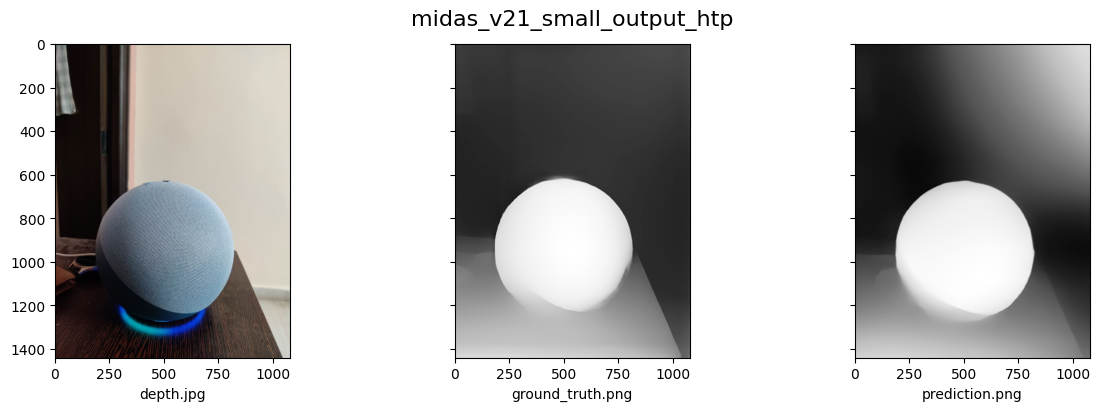

MiDaS\midas_v21_small_output_cpu


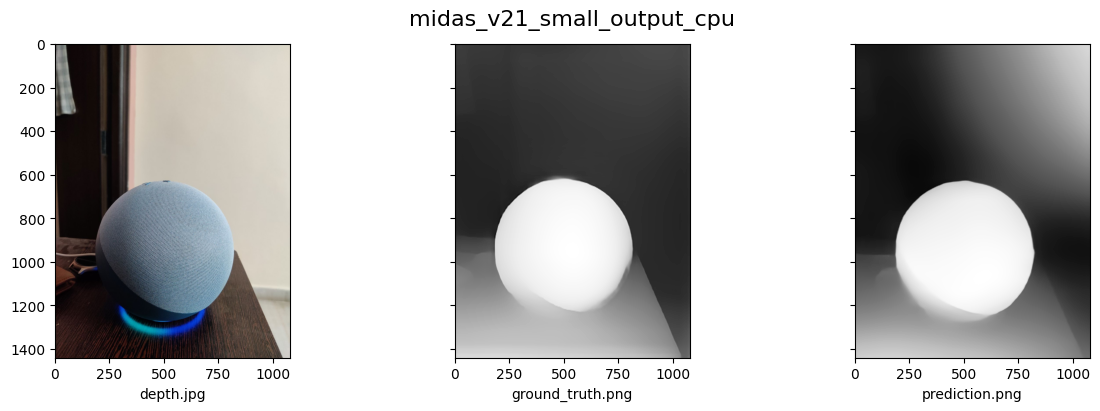

In [25]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, imshow, axis
from matplotlib.image import imread
import random as rand
from scipy import ndimage

def showImagesHorizontally(majors,runtime):
    fig, axs = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True,
                        sharex=True, sharey=True)
    for nn, ax in enumerate(axs.flat):
        column = majors[nn]
        column_rec_name = column.replace('\n', '_').replace(' ', '_')
        image = imread(majors[nn])            
        if nn==0:
            rotated_img = ndimage.rotate(image, 270)
            ax.imshow(rotated_img,cmap='Greys_r',)
        else:
            ax.imshow(image,cmap='Greys_r',)
        ax.set_xlabel(majors[nn].split("\\")[-1])
    fig.suptitle(runtime.split("\\")[-1], fontsize=16)
    plt.show()

for i in dict_folder_wise.keys():
    index = 0 #(change index b/w 0-number_of_images here to see output for different images)
    print(i)
    showImagesHorizontally(dict_folder_wise[i][index],i)

### Inference for Midas v21 small

In [26]:
%%cmd 
qnn-profile-viewer --input_log MiDaS/midas_v21_small_output_htp/qnn-profiling-data_0.log

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Depth_Estimation>qnn-profile-viewer --input_log MiDaS/midas_v21_small_output_htp/qnn-profiling-data_0.log
Log File Created: Sat Jun 15 01:13:37 2024
Time Scale: 1e-06
Epoch Timestamp: 1718439217729759 Steady Clock Timestamp: 912224919451
Generated using: 
qnn-profile-viewer v2.21.0.240401120655_85612
qnn-net-run        v2.21.0.240401120655_85612
Backend            v2.21.0.240401120655_85612

Qnn Init/Prepare/Finalize/De-Init/Execute/Lib-Load Statistics:
------------------------------------------------------------
Init Stats:
-----------
    NetRun: 32093 us
    Backend (RPC (load binary) time): 14701 us
    Backend (QNN accelerator (load binary) time): 14210 us
    Backend (Accelerator (load binary) time): 13466 us
    Backend (QNN (load binary) time): 32075 us

Compose Graphs Stats:
--------------
    NetRun: 0 us

Finalize Stats:
---------------

De-Init Stats:
----